In [1]:
import os

import xarray as xr
import numpy as np

# %matplotlib widget
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib
# TkAgg is usually built-in and very fast

import sys

%load_ext autoreload
%autoreload 1

sys.path.insert(0, '../../instrument/')
from Agilent.instr_N9928A import N9928A
from Valon.instr_Valon5015 import Valon5015

sys.path.insert(0, '../../pattern/')
%aimport helper_sweep
from helper_sweep import do_sweep

In [2]:
_address = "10.0.100.110"
_instr = N9928A(_address)

Connected to N9928A [10.0.100.110:5025].


In [ ]:
dr_address = "10.0.100.24"
dr_instr = Valon5015(dr_address)

In [69]:
_instr.reference('EXT')
_instr.center_frequency(8.431375e9)
_instr.span(50e3)
_instr.if_frequency(1e3)
_instr.average(5, mode='sweep')
_instr.points(101)
_instr.power(-10)

In [70]:
dr_instr.frequency(5e9)
dr_instr.power(0)

In [71]:
config_device = [dr_instr]
config_sweep = [
    [
        [dr_instr.frequency, 'frequency_hz', np.arange(5e9, 8e9, 0.01e9)]
    ]
]

In [72]:
# config_device = [_instr, dr_instr]
# config_sweep = [
#     [
#         [_instr.power, 'power_dbm', np.arange(-30,3,10)]
#     ],
#     [
#         [dr_instr.frequency, 'freq_hz', np.array([5e9, 6e9])]
#     ]
# ]

In [73]:
dr_instr.output(1)

In [74]:
file_path = os.path.join(os.getcwd(), 'two_tone_1.zarr')
do_sweep(config_device, config_sweep, _instr.get_trace, file_path)

100%|██████████| 300/300 [14:38<00:00,  2.93s/it]


In [75]:
dr_instr.output(0)

In [76]:
file_path = 'two_tone_1.zarr'

with xr.open_zarr(file_path, consolidated=False) as f:
    raw_data = f['S21']

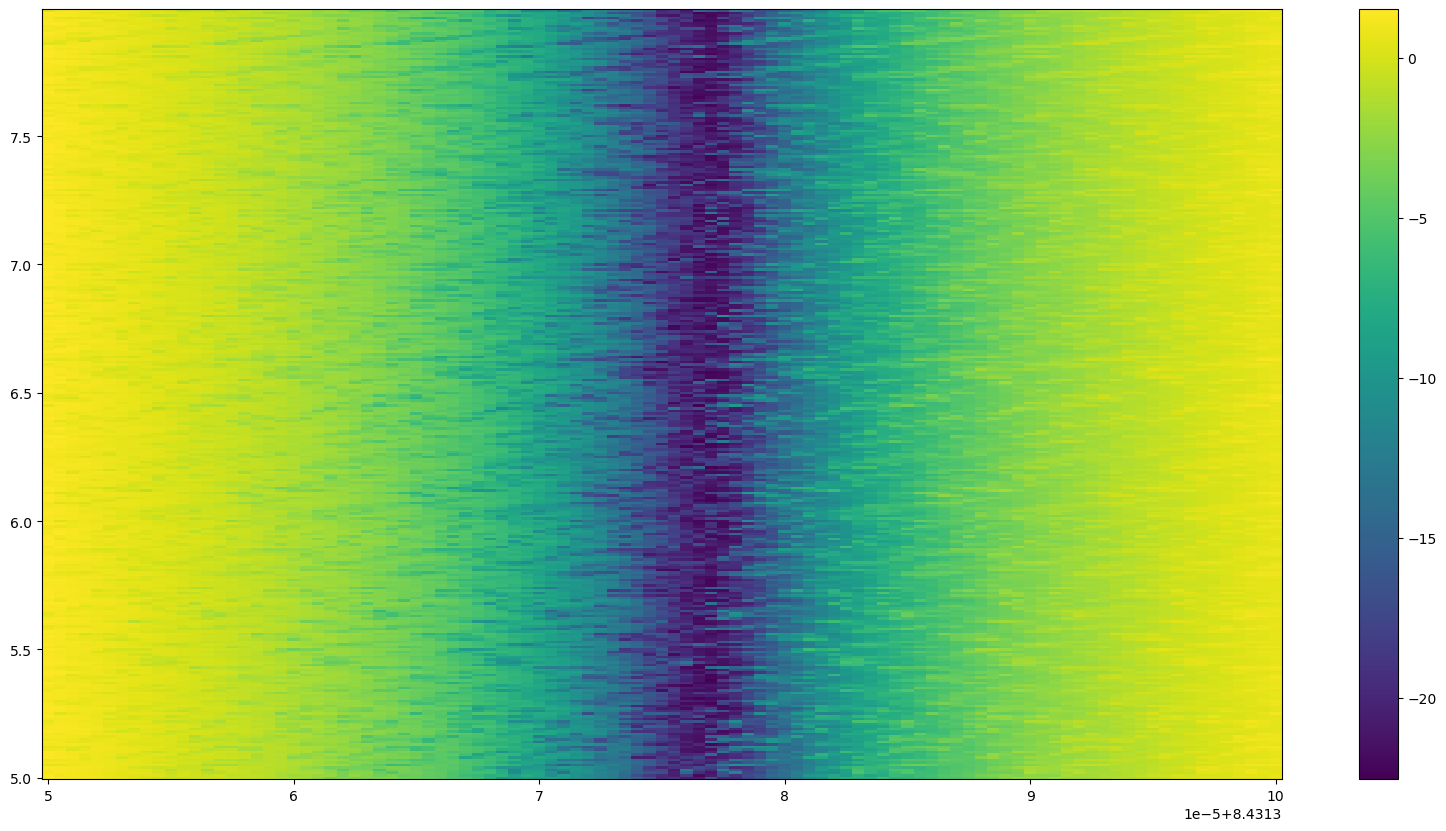

In [77]:
plt.figure(figsize = (20,10))

try:
    plt.pcolormesh(raw_data.N9928A_frequency_hz/1e9, raw_data.Valon_5015_frequency_hz/1e9, 20*np.log10(np.abs(raw_data)).squeeze())
    plt.colorbar()

    # for _frequency in raw_data.Valon_5015_frequency_hz:
    #     plt.plot(raw_data.N9928A_frequency_hz/1e9, 20*np.log10(np.abs(raw_data.sel(Valon_5015_frequency_hz=_frequency).squeeze())))
except:
    plt.plot(raw_data.N9928A_frequency_hz/1e9, 20*np.log10(np.abs(raw_data.squeeze())))

# plt.vlines(f_list, -50, -10, color='k')

plt.show()

In [23]:
# plt.figure(figsize = (20,10))
#
# try:
#     # plt.pcolormesh(raw_data.N9928A_frequency_hz/1e9, raw_data.N9928A_power_dbm, 20*np.log10(np.abs(raw_data).max(dim='N9928A_if_frequency_hz')).squeeze())
#     # plt.colorbar()
#
#     for _power in raw_data.N9928A_power_dbm:
#         plt.plot(raw_data.N9928A_frequency_hz/1e9, 20*np.log10(np.abs(raw_data.sel(N9928A_power_dbm=_power).squeeze())))
# except:
#     plt.plot(raw_data.N9928A_frequency_hz/1e9, 20*np.log10(np.abs(raw_data.squeeze())))
#
# # plt.vlines(f_list, -50, -10, color='k')
#
# plt.show()